# Module 9 — Pipelines & Interpretability (SHAP)
#
**สิ่งที่ต้องรู้ก่อนเรียนโมดูลนี้ (prerequisites):**
- จาก Module 4/5: SECOM, class imbalance, `scale_pos_weight`, average precision, TimeSeriesSplit
- จาก Day 1: linear/logistic regression พื้นฐาน
#
**เคสของโมดูลนี้:** โมดูลก่อน ๆ เราประกอบ workflow ด้วยมือ — impute ที, scale ที, fit ที — ครั้งเดียวไม่พัง แต่พอต้อง cross-validate, ลองหลายโมเดล, ส่งมอบให้ทีมอื่น **การลืม fit หนึ่งขั้น = leakage หรือบั๊กเงียบ** scikit-learn `Pipeline` คือคำตอบ: ร้อยทุกขั้นเป็นวัตถุเดียว fit ครั้งเดียว และเมื่อโมเดลตัดสิน "ชิ้นนี้ FAIL" ห้องสอบเทียบต้องตอบผู้ตรวจได้ว่า **ทำไม** — เครื่องมือคือ SHAP

In [1]:
from pathlib import Path


def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise FileNotFoundError("ไม่พบ datasets/ — รันโน้ตบุ๊กจากใน repo")


DATA = data_dir()

**Dataset (โปรดอ่านก่อนใช้งาน):**
#
- *UCI SECOM* — McCann, M. & Johnston, A. (2008). *SECOM* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C54305 (CC BY 4.0)
- ไฟล์: `datasets/secom.zip` — 1,567 แถว × 590 features จากเซนเซอร์สายผลิตเซมิคอนดักเตอร์, label −1 = PASS / +1 = FAIL (104 fails ~6.6%), ค่าหายหนักทุก feature
- แมปเข้าเคสเมโทรโลยี: features → การวัดของ probe/เซนเซอร์บนสายผลิต, label → ผลตรวจ final gauge (PASS/FAIL) — โมเดลของเราต้อง (1) ทนค่าหาย, (2) วัดผลซื่อสัตย์, (3) **อธิบายการตัดสินใจได้ต่อผู้ตรวจ**

## เตรียมข้อมูล — ลอดเดอร์เดียวกับ Module 4

ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)

แบ่งตามเวลา (แถวเรียงตามลำดับผลิต)

In [2]:
import io  # noqa: E402
import zipfile  # noqa: E402

import matplotlib.pyplot as plt  # noqa: E402
import numpy as np  # noqa: E402
import polars as pl  # noqa: E402

plt.rcParams["font.family"] = [
    "DejaVu Sans",
    "Noto Sans Thai",
    "Leelawadee UI",
    "Tahoma",
    "Thonburi",
]

with zipfile.ZipFile(DATA / "secom.zip") as z:
    feats = pl.read_csv(
        io.BytesIO(z.read("secom.data")),
        separator=" ",
        has_header=False,
        new_columns=[f"feature_{i}" for i in range(1, 591)],
        schema_overrides=[pl.Float64] * 590,
        null_values="NaN",
    )
    lab = pl.read_csv(
        io.BytesIO(z.read("secom_labels.data")),
        separator=" ",
        quote_char='"',
        has_header=False,
        new_columns=["label", "timestamp"],
    )

secom = feats.with_columns(lab["label"].alias("label"))
X_all = secom.drop("label")
y_all = (secom["label"] == 1).to_numpy().astype(int)  # 1 = FAIL
names = X_all.columns
X = X_all.to_numpy()
n = len(y_all)
cut = int(n * 0.8)
Xtr, Xte, ytr, yte = X[:cut], X[cut:], y_all[:cut], y_all[cut:]
print(
    f"{n} แถว | train {cut} (FAIL {ytr.sum()}) | test {n - cut} (FAIL {
        yte.sum()
    })"
)

1567 แถว | train 1253 (FAIL 87) | test 314 (FAIL 17)


## 1. ทำไมต้อง Pipeline — จุดพังของการประกอบมือ
#
โฟลว์จริงของโมดูลนี้มีอย่างน้อย 3 ขั้นก่อนโมเดล: **impute** (ค่าหาย), **คัด feature** (590 ตัวเยอะเกิน), **scale** (สำหรับโมเดลที่แพ้สเกล) การเขียนตรง ๆ มีบั๊กคลาสสิกสองแบบ:
#
1. **ลืมแยก fit** — `imputer.fit(Xทั้งหมด)` ก่อนแบ่ง train/test → สถิติของ test (รวม label ผ่านการคัด feature) หลุดเข้า train = leakage
2. **โค้ดซ้ำทุกที่** — ทำครบ 3 ขั้นซ้ำในทุก fold ของ CV, ทุกโมเดลที่ลอง, ตอน deploy — ที่ไหนหลุดขั้น ที่นั่นพัง
#
`Pipeline` รวมขั้นตอนเป็นวัตถุเดียว: เรียก `fit` ครั้งเดียว มันจะ fit transformer ทุกตัว **จากข้อมูลที่เห็นตอนนั้นเท่านั้น** แล้วค่อยส่งต่อให้ขั้นถัดไป — CV ก็เรียก pipeline เดียวกัน ไม่มีทางลืม

ขั้นสุดท้ายคือ estimator ตัวจริง

In [3]:
from sklearn.impute import SimpleImputer  # noqa: E402
from sklearn.linear_model import LogisticRegression  # noqa: E402
from sklearn.pipeline import Pipeline  # noqa: E402

pipe_demo = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)
print("ขั้นตอนใน pipeline:", [s[0] for s in pipe_demo.steps])

ขั้นตอนใน pipeline: ['impute', 'model']


(ตอนนี้ `pipe_demo.fit(X, y)` เดียว จะ impute → fit logistic ให้ครบตามลำดับเอง — ต่อไปเราจะใช้โครงนี้จริงกับกรณีที่ leak)

## 2. Leakage ตัวจริง: คัด feature ก่อนแล้วค่อย CV
#
เคสที่พบบ่อยที่สุดในงานจริง: "590 feature เยอะไป — งั้นคัด 20 ตัวที่สัมพันธ์กับ label สุดก่อน แล้วค่อย cross-validate" ฟังดูเหมาะสม **แต่การคัดที่ใช้ y ของทุกแถว (รวมอนาคต) คือการปล่อยให้ fold test ช่วยเลือกคำตอบ** — ผล CV จะฟูมเท็จ
#
เราทำทั้งสองแบบเทียบกันบน SECOM (คะแนน = average precision, CV แบบ TimeSeriesSplit):
#
- **baseline**: ใช้ทุก 590 features (ไม่คัด)
- **honest**: คัด feature **ข้างใน pipeline** — ทุก fold คัดใหม่จาก train ของ fold นั้น
- **leaky**: คัด feature **ก่อน CV** ด้วย y ทั้ง dataset

แบบ leaky: impute + คัด feature ด้วย y ทั้ง dataset ก่อน แล้วค่อย CV

In [4]:
from sklearn.feature_selection import SelectKBest, f_classif  # noqa: E402
from sklearn.linear_model import LogisticRegression  # noqa: E402
from sklearn.model_selection import TimeSeriesSplit  # noqa: E402
from sklearn.model_selection import cross_val_score  # noqa: E402
from sklearn.preprocessing import StandardScaler  # noqa: E402

tscv = TimeSeriesSplit(n_splits=5)
scoring = "average_precision"

logreg = LogisticRegression(
    max_iter=5000, class_weight="balanced", random_state=42
)

baseline = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", logreg),
    ]
)

honest = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("select", SelectKBest(f_classif, k=20)),  # คัดใหม่ทุก fold อัตโนมัติ
        ("scale", StandardScaler()),
        ("model", logreg),
    ]
)

imp_full = SimpleImputer(strategy="median").fit(X)
X_imp_full = imp_full.transform(X)
sel_leak = SelectKBest(f_classif, k=20).fit(X_imp_full, y_all)
X_sel_leak = sel_leak.transform(X_imp_full)
leaky = Pipeline([("scale", StandardScaler()), ("model", logreg)])

print(
    f"baseline (590 features)      CV AP: {
        cross_val_score(
            baseline, Xtr, ytr, scoring=scoring, cv=tscv
        ).mean():.3f}"
)
print(
    f"honest  (คัดข้างใน pipeline) CV AP: {
        cross_val_score(
            honest, Xtr, ytr, scoring=scoring, cv=tscv
        ).mean():.3f}"
)
print(
    f"leaky   (คัดก่อน CV)         CV AP: {
        cross_val_score(
            leaky, X_sel_leak[:cut], ytr, scoring=scoring, cv=tscv
        ).mean():.3f}"
)

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  97 141 149 178 179 186 189 190 191 192 193 194
 226 229 230 231 232 233 234 235 236 237 240 241 242 243 256 257 258 259
 260 261 262 263 264 265 266 276 284 313 314 315 322 325 326 327 328 329
 330 364 369 370 371 372 373 374 375 378 379 380 381 394 395 396 397 398
 399 400 401 402 403 404 414 422 449 450 451 458 461 462 463 464 465 466
 481 498 501 502 503 504 505 506 507 508 509 512 513 514 515 528 529 530
 531 532 533 534 535 536 537 538] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base

baseline (590 features)      CV AP: 0.075
honest  (คัดข้างใน pipeline) CV AP: 0.108
leaky   (คัดก่อน CV)         CV AP: 0.192


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/feature_selection/_univariate_selection.py:110: UserWarning: Features [  5  13  42  49  52  69  74  96 137 145 174 175 182 185 186 187 188 189
 190 202 205 221 224 225 226 227 228 229 230 231 232 235 236 237 238 248
 249 250 251 252 253 254 255 256 257 258 268 276 305 306 307 314 317 318
 319 320 321 322 334 339 355 360 361 362 363 364 365 366 369 370 371 372
 382 383 384 385 386 387 388 389 390 391 392 402 410 437 438 439 446 449
 450 451 452 453 454 466 469 485 488 489 490 491 492 493 494 495 496 499
 500 501 502 512 513 514 515 516 517 518 519 520 521 522] are constant.
  warnings.warn("Fe

อ่านผล: ตัวเลข leaky **สูงกว่า honest เกือบ 2 เท่า** (≈0.19 vs ≈0.11) — ไม่ใช่เพราะโมเดลเก่งขึ้น แต่เพราะการคัด feature ที่แอบดู y ของอนาคตทำให้ "โจทย์ง่ายลง" ในทุก fold ถ้ารายงาน 0.19 ไปในเอกสาร ผู้ใช้จริงจะเจอประสิทธิภาพระดับ 0.1 แล้วถามว่าเกิดอะไรขึ้น
#
> **กฎ:** ทุกขั้นที่แตะ y (คัด feature, การเลือก hyperparameter, encoding แบบ target-based) ต้องอยู่ **ข้างใน** pipeline — เห็นเฉพาะ train ของ fold นั้น ๆ เท่านั้น
#
(เชิงเทคนิค: แม้แต่ impute ก่อนแบ่งก็ leak เล็ก ๆ แอบแฝง — กับ SECOM ผลกระทบจิ๋ว แต่กิจวัตรที่ถูกคือใส่ไว้ใน pipeline เสมอ ฟรีและปิดข้อกังขาทั้งหมด)

## 3. ประกอบ harness จริง — เปลี่ยนโมเดลที่ขั้นสุดท้ายบรรทัดเดียว
#
จุดขายที่สองของ pipeline: เทียบโมเดลหลายตัวบน **กรรมการเดียวกัน** — เปลี่ยนแค่ขั้นสุดท้าย เราเทียบ logistic regression กับ XGBoost (ที่มี `scale_pos_weight` กับ class imbalance)

In [5]:
from xgboost import XGBClassifier  # noqa: E402

spw = (ytr == 0).sum() / (ytr == 1).sum()
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    scale_pos_weight=spw,
    random_state=42,
    eval_metric="logloss",
)

pipe_xgb = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("model", xgb),  # ต้นไม้ไม่ต้อง scale — ขั้นน้อยลงเอง
    ]
)

pipe_log = Pipeline(
    [
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("model", logreg),
    ]
)

for name, p in [
    ("logistic (590 feats)", pipe_log),
    ("XGBoost (590 feats)", pipe_xgb),
]:
    scores = cross_val_score(p, Xtr, ytr, scoring=scoring, cv=tscv)
    print(
        f"{name:22s} CV AP: {scores.mean():.3f}  (folds: "
        f"{np.round(scores, 3)})"
    )

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrol

/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


logistic (590 feats)   CV AP: 0.075  (folds: [0.116 0.13  0.038 0.052 0.039])


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/sklearn/impute/_base.py:647: UserWarning: Skipping features without any observed values: [ 85 109 110 111 220 244 245 246 358 382 383 384 492 516 517 518]. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


XGBoost (590 feats)    CV AP: 0.187  (folds: [0.15  0.088 0.076 0.577 0.043])


วัดบน test ครั้งเดียวตอนจบ (เปิดกล่องหลังตัดสินใจเสร็จ) — และเก็บโมเดล XGBoost ไว้ใช้ตอน SHAP:

In [6]:
from sklearn.metrics import average_precision_score  # noqa: E402

pipe_xgb.fit(Xtr, ytr)
ap_test = average_precision_score(yte, pipe_xgb.predict_proba(Xte)[:, 1])
print(f"XGBoost test AP: {ap_test:.3f}")
print(
    "อ่าน: SECOM เป็นปัญหาที่ยากจริง — 17 fails ใน test, 590 features "
    "ที่ส่วนใหญ่คือ noise"
)

XGBoost test AP: 0.079
อ่าน: SECOM เป็นปัญหาที่ยากจริง — 17 fails ใน test, 590 features ที่ส่วนใหญ่คือ noise


## 4. SHAP — อธิบายการตัดสินใจรายชิ้นและราย feature
#
ค่า SHAP ของ prediction หนึ่งชิ้นตอบคำถาม: "**feature ไหนดันคำตอบไปทาง FAIL มากที่สุด**" โดยถอด prediction ออกเป็นส่วน ๆ (base value + ผลรวมส่วนของแต่ละ feature) — ในงานเมโทรโลยี นี่คือ **audit trail** ที่ผู้ตรวจต้องการ: ไม่ใช่แค่ "เครื่องบอกว่า FAIL" แต่ "FAIL เพราะช่องวัด X ต่ำกว่าปกติและช่องวัด Y สูงผิดปกติ"
#
เราใช้ `TreeExplainer` (เร็วมากสำหรับต้นไม้) บนโมเดล XGBoost ใน pipeline — impute ส่วน preprocessing ด้วยตัวเองก่อนส่งเข้า explainer แล้วอยากได้ชื่อ feature บนกราฟ เราจึงส่งเป็น DataFrame (pandas — เจอครั้งแรกในหลักสูตร เพราะ SHAP รับ DataFrame แล้วอ่านชื่อคอลัมน์ให้เอง):

impute test ด้วย transformer ที่ fit จาก train แล้ว (นำมาจาก pipeline — ไม่ fit ใหม่)

In [7]:
import pandas as pd  # noqa: E402
import shap  # noqa: E402

model = pipe_xgb.named_steps["model"]
imputer = pipe_xgb.named_steps["impute"]

Zte = pd.DataFrame(imputer.transform(Xte), columns=names)
explainer = shap.TreeExplainer(model)
sv = explainer(Zte.iloc[:200])  # Explanation ของ 200 ชิ้นแรกใน test
print(
    "shap values:",
    sv.shape,
    "| base value:",
    round(float(explainer.expected_value), 3),
)

shap values: (200, 590) | base value: -0.023


/Users/utarn/projects/ml-metrology/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


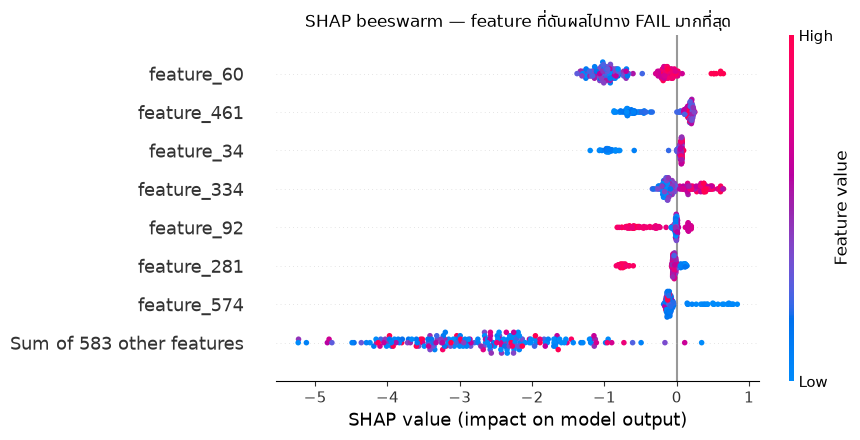

In [8]:
plt.figure()
shap.plots.beeswarm(sv, max_display=8, show=False)
plt.gcf().set_size_inches(9, 4.5)
plt.title("SHAP beeswarm — feature ที่ดันผลไปทาง FAIL มากที่สุด")
plt.tight_layout()
plt.show()

อ่าน beeswarm: แต่ละแถวคือ feature หนึ่งตัว แต่ละจุดคือชิ้นหนึ่งชิ้น
#
- แกนนอน = ค่า SHAP (ดันไปทาง FAIL เป็นบวก) — `feature_060` มีจุดกระจายไกลไปทางบวกมาก = ตัวการอันดับหนึ่ง
- สีจุด = ค่า feature สูง/ต่ำ (แดงสูง น้ำเงินต่ำ) — บน `feature_060` จุดแดง (ค่าสูง) อยู่ทาง FAIL: **ค่าช่องนี้สูงผิดปกติ → แนวโน้ม FAIL**
- ตัวอักษร `feature_XXX` คือหมายเลขเซนเซอร์บนสายผลิตจริง — ในงานของคุณ ชื่อพวกนี้คือ "ช่องวัดที่ 60" ที่ทีมวิศวกรต้องไปดีดดูก่อนคนอื่น
#
ต่อไปรายชิ้น: หาชิ้นที่โมเดลมั่นใจ FAIL สุด แล้วอธิบายด้วย waterfall

ชิ้นที่ 30 — โมเดลให้ P(FAIL) = 0.53 (label จริง = PASS)


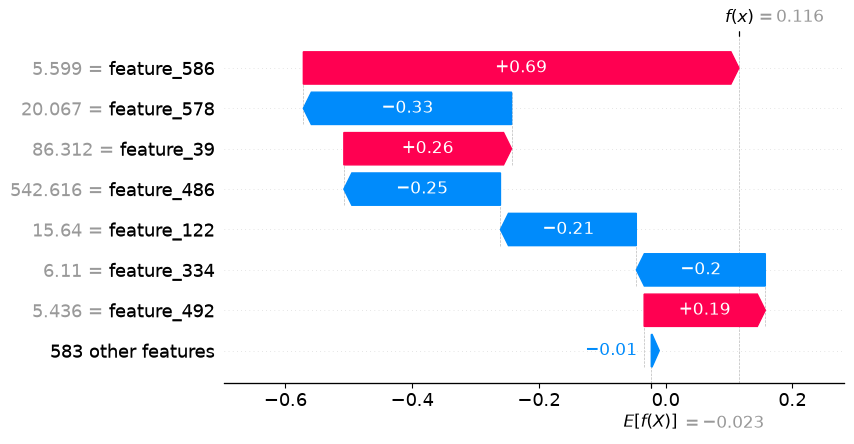

In [9]:
proba = pipe_xgb.predict_proba(Xte)[:, 1][:200]
i_fail = int(np.argmax(proba))
print(
    f"ชิ้นที่ {i_fail} — โมเดลให้ P(FAIL) = {proba[i_fail]:.2f} (label จริง = {
        'FAIL' if yte[i_fail] == 1 else 'PASS'
    })"
)

plt.figure()
shap.plots.waterfall(sv[i_fail], max_display=8, show=False)
plt.gcf().set_size_inches(8, 4.5)
plt.show()

อ่าน waterfall จากล่างขึ้นบน: เริ่มจาก base value (ค่าเฉลี่ยโมเดลกับทุกชิ้น) แล้วแต่ละแท่งดันไปทาง FAIL (แดง) หรือ PASS (น้ำเงิน) จบที่ f(x) = ผลลัพธ์จริงของชิ้นนี้ — แท่งใหญ่สุดคือ **เหตุผลหลัก** ที่ชิ้นนี้ถูกชี้ว่า FAIL นี่คือแถลงการณ์ที่ติดไปกับใบตรวจได้เลย
#
และสังเกตประเด็นละเอียดแต่สำคัญ: ชิ้นที่โมเดลมั่นใจ FAIL สุด จริง ๆ คือ **PASS** — SHAP อธิบาย "เหตุผลของโมเดล" ไม่ใช่ "ความจริง" โมเดลผิดก็ต้องอธิบายได้ว่าผิดเพราะ feature ไหนหลอกมัน — ในงานจริงนี่คือจุดเริ่มของการไล่หาสัญญาณหลอก (และอาจพบเซนเซอร์เก้อที่ควรถอดออกจากโมเดล)
#
ปิดท้ายด้วย dependence plot — รูปทรงความสัมพันธ์ของตัวการอันดับหนึ่ง:

ตัวการอันดับหนึ่ง: feature_60


<Figure size 640x480 with 0 Axes>

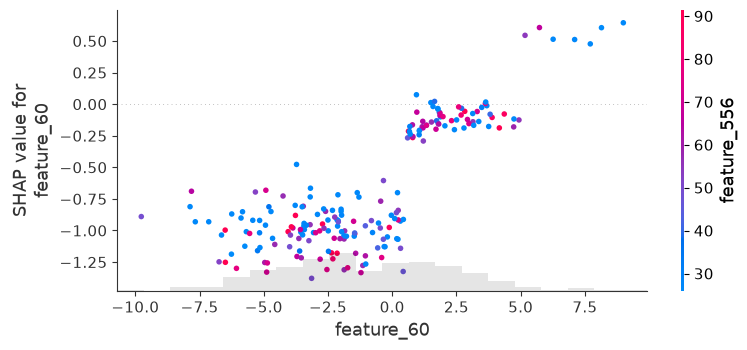

In [10]:
top_feature = int(np.abs(sv.values).mean(axis=0).argmax())
print("ตัวการอันดับหนึ่ง:", names[top_feature])

plt.figure()
shap.plots.scatter(sv[:, top_feature], color=sv, show=False)
plt.gcf().set_size_inches(8, 3.6)
plt.tight_layout()
plt.show()

**สรุปโมดูล:** `Pipeline` ร้อยทุกขั้นเป็นวัตถุเดียว — ปิด leakage ทั้งแบบเห็นชัด (คัด feature ก่อน CV: CV AP ฟูมจาก ~0.11 เป็น ~0.19) และแบบเห็นยาก (impute ก่อนแบ่ง) · เทียบโมเดลได้ด้วยการเปลี่ยนขั้นสุดท้ายบรรทัดเดียวบนกรรมการเดียวกัน · SHAP แปลงโมเดลกล่องดำเป็น audit trail รายชิ้น (waterfall) และราย feature (beeswarm, scatter) — ครบสองเงื่อนไขของโมเดลที่ห้องสอบเทียบยอมรับได้: วัดผลซื่อสัตย์ และอธิบายตัวเองได้